<div dir="ltr" align="center">

  <span style="font-size: 60px; color: #0B3C78; font-weight: 700;">
    Artificial Intelligence
  </span><br><br>

  <span style="font-size: 22px; color: #1F5FA8; font-weight: 500;">
    Computer Engineering Department
  </span><br>

  <span style="font-size: 20px; color: #1F5FA8; font-weight: 500;">
    Sharif University of Technology
  </span><br><br>

  <span style="font-size: 22px; color: #1F7A8C; font-weight: 600;">
    Spring 2026
  </span><br><br>

  <span style="font-size: 24px; color: #145DA0; font-weight: 700;">
    Practical Assignment
  </span><br><br>

  <span style="font-size: 22px; color: #3A7CC2; font-weight: 600;">
    Constraint Satisfaction Problem
  </span><br><br><br>

</div>

---

- Instructor: Dr.Tanghatari
- Practical Designer: Baran Hosseini

---

### Student Information

- Name: Arvin
- Last Name: Baghal Asl
- Student Number: 403105793

---

### Instructions

- Make sure to:
  - Fill in your personal information above.
  - Run all the cells in the notebook and make sure your code runs truly 



# 🗺️ Map Coloring as a Constraint Satisfaction Problem

## Problem Overview
This assignment models the **Map Coloring Problem** within a CSP framework. We evaluate the efficiency of various search strategies on **Organic Planar Graphs**—structures generated via Delaunay triangulation of random points to simulate realistic geographical adjacencies.

---

## Search Strategies to Implement
We will implement and compare four distinct backtracking-based approaches:

1.  **Naive Backtracking:** Standard depth-first search without optimization.
2.  **Backtracking + Heuristics (Static):** Integration of *Minimum Remaining Values* (MRV) and *Least Constraining Value* (LCV) using static domain initialization.
3.  **Backtracking + Heuristics + Incremental Filtering:** MRV and LCV combined with lightweight consistency checks to prune domains dynamically.
4.  **Backtracking + Heuristics + Forward Checking:** Integration of MRV, LCV, and *Forward Checking* (FC) for early detection of failure states.

---

## Objectives & Methodology

### 1. Data Generation
- Construct organic graphs using **Delaunay Triangulation**.
- Ensure the resulting graphs are planar to maintain the properties of physical maps.

### 2. Heuristic Evaluation
- **The MRV Paradox:** Analyze why MRV loses effectiveness when domains remain static.
- **Consistency Enforcement:** Observe how incremental domain filtering restores the utility of the MRV heuristic by maintaining dynamic domain sizes.

---



In [1]:
# ============================================================
# 0. Setup: Imports and Configuration
# ============================================================

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
import time

# Plot styling
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 110


## 1. CSP Formulation for Map Coloring

We consider a map divided into regions (e.g., countries or states) and aim to assign a color to each region such that:

1. Each region receives exactly one color.  
2. No two adjacent regions share the same color.

This defines a **CSP** with the following components:

- **Variables:** regions (graph nodes)  
- **Domains:** available colors (using 4, per the Four-Color Theorem)  
- **Constraints:** adjacent regions must have distinct colors  

Instead of using a real map, we generate an **organic planar graph** procedurally:

1. Sample random points in the unit square.  
2. Compute their **Delaunay triangulation**.  
3. Use triangulation edges to define adjacency relationships.  

This process yields planar, “map-like” graphs suitable for CSP experimentation.


In [2]:
# ============================================================
# 1. "Organic" Planar Map (Graph)
# ============================================================

np.random.seed(42)    # For reproducibility
num_regions = 50    

points = np.random.rand(num_regions, 2)

# Delaunay triangulation
tri = Delaunay(points)

# Build the graph
G = nx.Graph()
for i in range(num_regions):
    G.add_node(i, geo_pos=(points[i, 0], points[i, 1]))

for simplex in tri.simplices:
    a, b, c = simplex
    G.add_edge(a, b)
    G.add_edge(b, c)
    G.add_edge(c, a)

variables = list(G.nodes())
neighbors = {node: list(G.neighbors(node)) for node in G.nodes()}

colors = [
    "#8B0000",  # deep red 
    "#003366",  # deep navy blue
    "#00BFFF",  # icy bright blue
    "#4B0082"   # dark purple
]

print(f"Generated planar map with {num_regions} regions and {G.number_of_edges()} borders.")


Generated planar map with 50 regions and 136 borders.


## 2. Visualizing the Uncolored Map

Before we start coloring, let’s just visualize the graph structure.

We want a layout that is:

- Consistent with the underlying geometry (points in the unit square),
- But a bit “expanded” to reduce overlap and clutter.

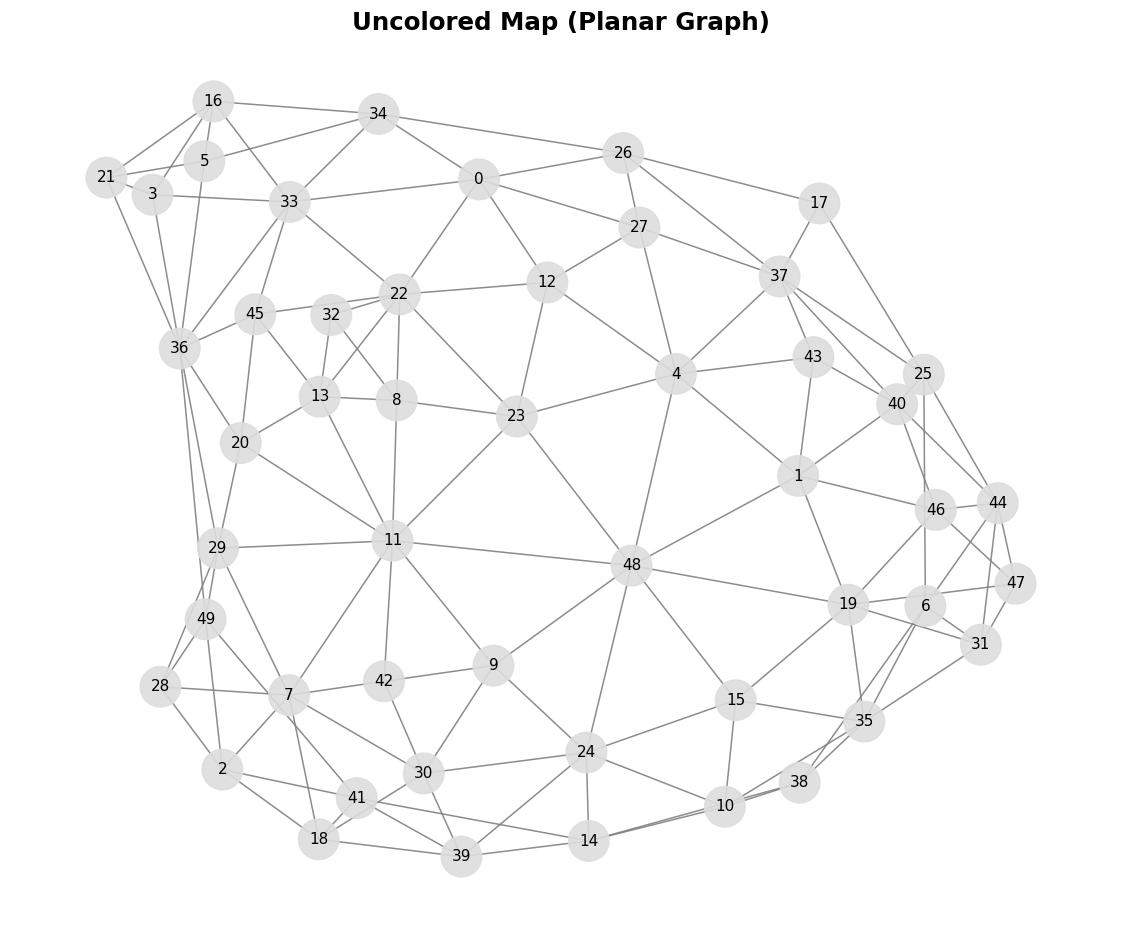

In [3]:
# ============================================================
# 2. Layout and Basic Drawing Utilities 
# ============================================================

def compute_layout(G, iterations=100, scale=2.0):
   
    geo_pos = nx.get_node_attributes(G, 'geo_pos')
    if not geo_pos:
        geo_pos = nx.random_layout(G)

    pos = nx.spring_layout(
        G,
        pos=geo_pos,      
        seed=42,            
        iterations=iterations,
        scale=scale
    )

    nx.set_node_attributes(G, pos, 'pos')
    return pos


def draw_uncolored_map(G, title="Uncolored Map (Planar Graph)"):
    pos = nx.get_node_attributes(G, 'pos')
    if not pos:  
        pos = compute_layout(G)

    node_colors = ['#DDDDDD'] * G.number_of_nodes()

    plt.figure(figsize=(10, 8))
    nx.draw(
        G, pos,
        node_color=node_colors,
        with_labels=False,
        node_size=700,
        edge_color="gray",
        width=1.0,
        alpha=0.9
    )
    nx.draw_networkx_labels(G, pos, font_size=10, font_color='black')
    plt.title(title, fontsize=16)
    plt.axis('equal')
    plt.show()


def draw_colored_map(G, assignment, title="Colored Map"):
    pos = nx.get_node_attributes(G, 'pos')
    if not pos:  
        pos = compute_layout(G)

    node_colors = [assignment.get(node, '#DDDDDD') for node in G.nodes()]

    plt.figure(figsize=(10, 8))
    nx.draw(
        G, pos,
        node_color=node_colors,
        with_labels=False,  
        node_size=700,
        edge_color='gray',
        width=1.0,
        alpha=0.9
    )
    nx.draw_networkx_labels(G, pos, font_size=10, font_color='black')
    plt.title(title, fontsize=16)
    plt.axis('equal')
    plt.show()

pos = compute_layout(G, iterations=150, scale=2.0)
draw_uncolored_map(G)


## 3. CSP Core: Domains and Consistency

We will represent:

- `assignment`: a dictionary `var -> color` for variables already colored.
- `domains`: a dictionary `var -> list of possible colors` (dynamic for some solvers).
- `neighbors`: adjacency list for each variable.

We start with **full domains**: every variable can be any of the 4 colors.

We also need a basic **consistency check**:  
Given `var` and proposed `value`, is this consistent with the current partial assignment?


In [4]:
# ============================================================
# 3. Domains and Consistency
# ============================================================

# Initial domains: every variable starts with all 4 colors
initial_domains = {var: colors.copy() for var in variables}

def is_consistent(var, value, assignment, neighbors):
	"""
	Check if assigning 'value' to 'var' conflicts with any already assigned neighbor.
	Return True if consistent (no neighbor has the same color).
	"""
	neighbors_of_var = neighbors.get(var, [])
	for neighbor in neighbors_of_var:
		if assignment.get(neighbor) and value == assignment.get(neighbor):
			return False
		
	return True


## 4. Naive Backtracking

**Algorithm:**

1. Pick the **first unassigned variable** (in a fixed order).
2. Try its possible values in the given order (no heuristic ordering).
3. For each value:
   - If consistent with the current assignment:
     - Assign it and recurse.
   - If recursion fails, undo the assignment and try the next value.
4. If no value works, backtrack (dead end).

We’ll track:

- `calls`: how many times the backtracking function is invoked.
- `backtracks`: how many dead ends we hit.


Running Naive Backtracking...
Naive solution found? True
Naive: time = 18.7504s, calls = 6721394, backtracks = 6721343


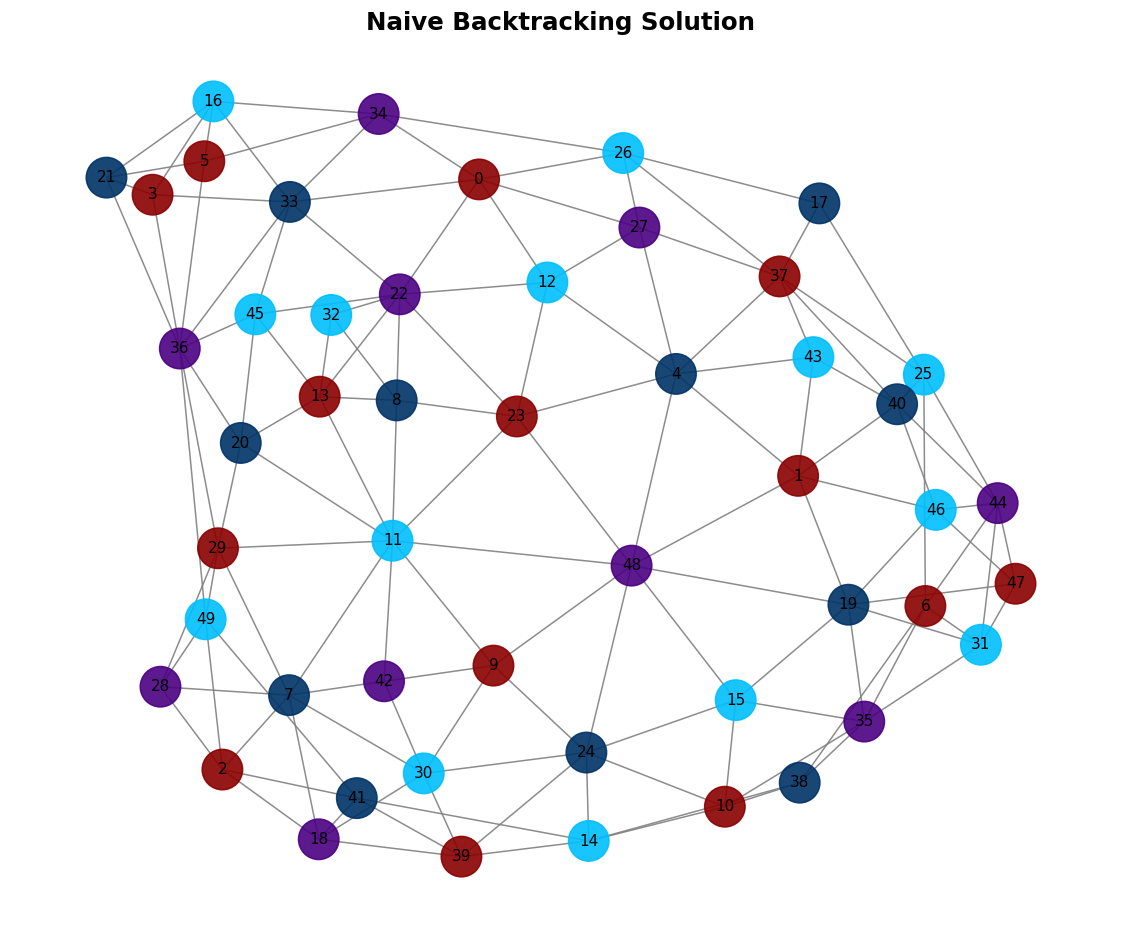

In [5]:
# ============================================================
# 4. Naive Backtracking (No Heuristics, No Inference)
# ============================================================

def backtrack_naive(assignment: dict, domains: dict, variables: list, neighbors: dict, stats: dict):
	"""
	Naive backtracking:
	- Variable selection: first unassigned variable (fixed order).
	- Value ordering: as they appear in domains[var].
	- Consistency: only check against assigned neighbors.
	"""

	stats['calls'] += 1
	
	# If all variables are assigned, we found a solution
	# 1. Select the first unassigned variable
	found_ans = True
	first_unassigned_var = None
	for var in variables:
		if var not in assignment:
			found_ans = False
			first_unassigned_var = var
			break
	if found_ans:
		return assignment
	
	# 2. Try each value in the current domain
	# we don't update domains in naive method
	for value in domains.get(first_unassigned_var, []):
		if is_consistent(first_unassigned_var, value, assignment, neighbors):
			assignment[first_unassigned_var] = value

			result =  backtrack_naive(assignment, domains, variables, neighbors, stats)
			if result is not None:
				return result

			del assignment[first_unassigned_var]
		
	# Dead end for this partial assignment
	stats['backtracks'] += 1
	return None

# Run Naive Backtracking
stats_naive = {'calls': 0, 'backtracks': 0}
domains_naive = {var: list(colors) for var in variables}

print("Running Naive Backtracking...")
start = time.time()
solution_naive = backtrack_naive({}, domains_naive, variables, neighbors, stats_naive)
time_naive = time.time() - start

print("Naive solution found?" , solution_naive is not None)
print(f"Naive: time = {time_naive:.4f}s, calls = {stats_naive['calls']}, backtracks = {stats_naive['backtracks']}")

if solution_naive is not None:
	draw_colored_map(G, solution_naive, title="Naive Backtracking Solution")


### Concept Check 

**Question:**  
Why can naive backtracking be very slow on larger CSPs?

**Think about:**
- The number of variables and possible combinations.
- How much information is pruned early vs late in the search.

### Answer:
Naive backtracking is slow because it tries every possible color combination blindly, without any lookahead. It only detects a conflict after it has already assigned colors to many nodes, then backtracks. Most of the time is wasted exploring dead ends. In our run, out of 6.7 million steps, almost all were backtracks. That huge number of wasted attempts makes it very slow for larger problems.


## 5. Heuristics: MRV and LCV

We now add two classic CSP heuristics:

1. **MRV (Minimum Remaining Values):**
   - For variable selection.
   - Pick the unassigned variable whose **domain is smallest**.
   - Intuition: choose the most constrained variable first; if it’s going to fail, fail early.

2. **LCV (Least Constraining Value):**
   - For value ordering.
   - For each possible value of a variable, estimate how many options it removes from its neighbors’ domains.
   - Try the value that leaves the **most flexibility** for neighbors first.

We first implement these heuristic helpers.


In [6]:
# ============================================================
# 5. MRV and LCV Heuristics (Helpers)
# ============================================================

def minimum_remaining_variable(assignment: dict, domains: dict, variables: list):
	"""
	MRV heuristic:
	- Consider only unassigned variables.
	- Return the one with the smallest domain size.
	"""
	mrv = None
	min_domain_size = len(colors) + 1
	for var in variables:
		if var not in assignment.keys():
			domain_size = len(domains.get(var))
			if domain_size < min_domain_size:
				mrv = var
				min_domain_size = domain_size
	
	return mrv

def least_constraining_value(var, domains: dict, neighbors: dict):
	"""
	LCV heuristic:
	- For each value in domains[var], count how many neighbor-domain entries
		it would conflict with (i.e., how many neighbors currently allow that value).
	- Return values ordered from least constraining (fewest conflicts) to most.
	"""
	conflict_counts = {}
	for value in domains.get(var, []):
		conflicts = 0
		for neighbor in neighbors.get(var, []):
			if value in domains.get(neighbor, []):
				conflicts += 1
		
		conflict_counts[value] = conflicts
	
	sorted_values = sorted(conflict_counts, key=conflict_counts.get)
	return sorted_values


## 6. MRV + LCV with Static Domains (Paradox Version)

We now use MRV and LCV, but domains never shrink during search:

- We still have `domains[var] = [all 4 colors]` for every unassigned variable.
- We do not remove values from domains when assigning neighbors.
- MRV sees all domain sizes as equal (always size 4), so it degenerates to basically “first unassigned variable” (up to tiebreaking).
- LCV has no effect on future domains, because they never change.


Let’s implement this **static** variant.


Running MRV + LCV (STATIC domains)...
MRV+LCV (static) solution found? True
MRV+LCV (static): time = 55.7098s, calls = 6721394, backtracks = 6721343


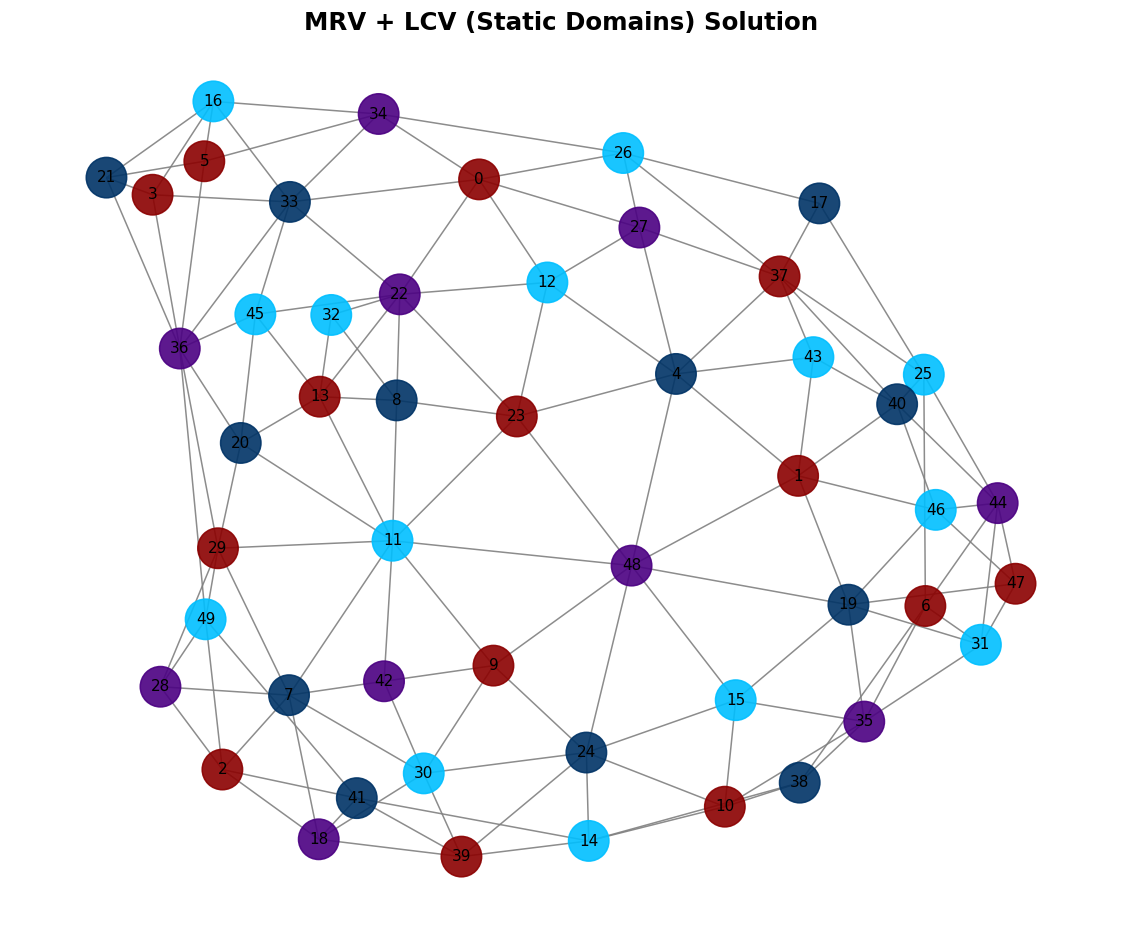

In [7]:
# ============================================================
# 6. Backtracking with MRV + LCV (Static Domains, No Inference)
# ============================================================

def backtrack_mrv_lcv_static(assignment: dict, domains: dict, variables: list, neighbors: dict, stats: dict):
	"""
	Backtracking with MRV + LCV but WITHOUT any domain updates.
	Domains are effectively static.
	"""
	stats['calls'] += 1
	
	# All variables assigned?
	if len(assignment) == len(variables):
		return assignment

	# Variable choice: MRV (but domain sizes do not shrink, so many ties)
	var = minimum_remaining_variable(assignment, domains, variables)

	# Value order: LCV (computed w.r.t static domains)
	values = least_constraining_value(var, domains, neighbors)
	for value in values:
		if is_consistent(var, value, assignment, neighbors):
			assignment[var] = value

			result =  backtrack_mrv_lcv_static(assignment, domains, variables, neighbors, stats)
			if result is not None:
				return result

			del assignment[var]
	
	stats['backtracks'] += 1
	return None

# Run MRV + LCV (static)
stats_mrv_lcv_static = {'calls': 0, 'backtracks': 0}
domains_static = {var: list(colors) for var in variables}

print("Running MRV + LCV (STATIC domains)...")
start = time.time()
solution_mrv_lcv_static = backtrack_mrv_lcv_static(
    {}, domains_static, variables, neighbors, stats_mrv_lcv_static
)
time_mrv_lcv_static = time.time() - start

print("MRV+LCV (static) solution found?" , solution_mrv_lcv_static is not None)
print(f"MRV+LCV (static): time = {time_mrv_lcv_static:.4f}s, calls = {stats_mrv_lcv_static['calls']}, backtracks = {stats_mrv_lcv_static['backtracks']}")

if solution_mrv_lcv_static is not None:
    draw_colored_map(G, solution_mrv_lcv_static, title="MRV + LCV (Static Domains) Solution")


### Concept Check : The Heuristic Paradox

Compare the metrics for:

- Naive Backtracking
- MRV + LCV (static domains)

**Questions:**

1. Are the numbers of recursive calls and backtracks similar or identical?
2. Which one is faster in wall-clock time?
3. Why might MRV + LCV be **slower** than naive, even though it uses “smarter” heuristics?

### Answer:
The numbers of calls and backtracks are identical because static domains make MRV always pick the first unassigned variable (all domain sizes are 4) and LCV always returns values in the same order (all conflict counts equal). So both solvers explore exactly the same search tree. However, MRV+LCV is slower in wall-clock time because, at every step, it wastes effort computing the MRV variable and LCV order without gaining any pruning. That extra overhead adds up over millions of calls, making it nearly three times slower than naive backtracking.

## 7. Lightweight Incremental Domain Filtering

To make MRV effective **without going all the way to full forward checking**, we add a simple, *local* domain filtering step.

When we assign `var = value`:

1. Restrict `var`'s domain to `[value]`.
2. Remove `value` from all **unassigned neighbors'** domains.
3. If any neighbor’s domain becomes empty, we detect a **dead end** immediately.

We do this in a **functional style**:

- Each recursive call receives its own `domains` dictionary.
- We create a new, updated copy when we assign a new variable.
- Backtracking then becomes trivial: we just discard that copy.

This is **lighter** than full forward checking in spirit:

- We only enforce `neighbor != value` locally.
- We do not perform deeper propagation (like AC-3, etc.).

However, it still makes domains **dynamic**, so MRV now sees real differences between variables.


Running MRV + LCV (incremental domain filtering)...
MRV+LCV (incremental) solution found? True
MRV+LCV (incremental): time = 0.0049s, calls = 51, backtracks = 0


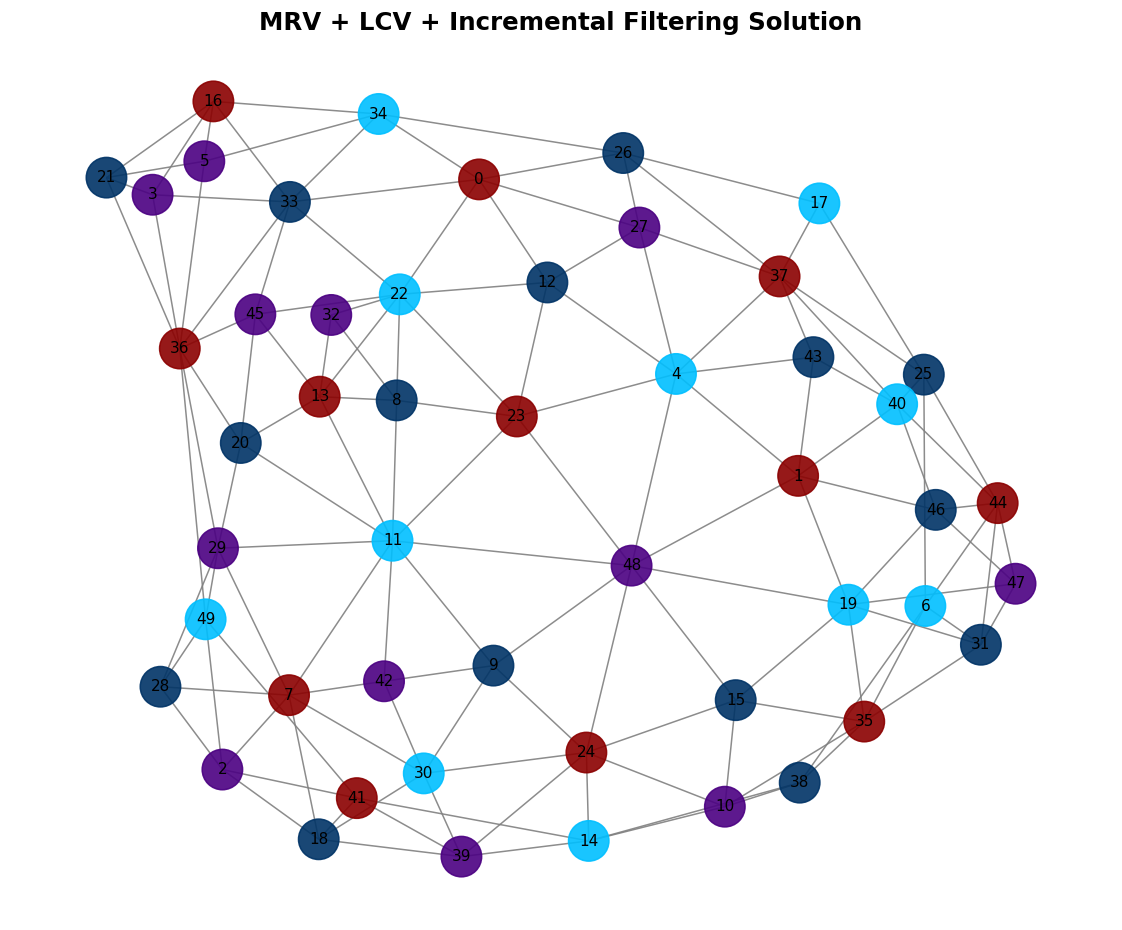

In [8]:
import copy
# ============================================================
# 7. MRV + LCV with Incremental Domain Filtering
# ============================================================

def apply_incremental_filter(var, value, assignment: dict, domains: dict, neighbors: dict):
	"""
	Lightweight incremental domain filtering:
	- Return a NEW domains dict after assigning (var = value).
	- Set var's domain to [value].
	- Remove 'value' from all unassigned neighbors' domains.
	- If any neighbor's domain becomes empty, return None (failure).
	"""
	# Copy domains for functional backtracking
	domains_copy = copy.deepcopy(domains)
	
	# Fix var's domain to the chosen value
	domains_copy[var] = [value]
	
	# Remove this value from neighbors' domains
	for neighbor in neighbors.get(var, []):
		if neighbor in assignment:
			continue

		if value in domains_copy.get(neighbor, []):
			domains_copy[neighbor].remove(value)
			if len(domains_copy[neighbor]) == 0:
				return None

	return domains_copy

def backtrack_mrv_lcv_incremental(assignment: dict, domains: dict, variables: list, neighbors: dict, stats: dict):
	"""
	Backtracking with:
	- MRV variable ordering (on current dynamic domains)
	- LCV value ordering
	- Incremental domain filtering (local, one-step look-ahead)
	"""
	stats['calls'] += 1
	
	# All variables assigned?
	if len(assignment) == len(variables):
		return assignment
	
	# Choose variable: MRV on current domains
	var = minimum_remaining_variable(assignment, domains, variables)
	
	# Value order: LCV on current domains
	values = least_constraining_value(var, domains, neighbors)
	for value in values:
		if is_consistent(var, value, assignment, neighbors):
			assignment[var] = value
			new_domains = apply_incremental_filter(var, value, assignment, domains, neighbors)
			if new_domains is not None:
				result =  backtrack_mrv_lcv_incremental(assignment, new_domains, variables, neighbors, stats)
				if result is not None:
					return result

			del assignment[var]
	
	stats['backtracks'] += 1
	return None

# Run MRV + LCV + incremental filtering
stats_mrv_lcv_inc = {'calls': 0, 'backtracks': 0}
domains_inc = {var: list(colors) for var in variables}

print("Running MRV + LCV (incremental domain filtering)...")
start = time.time()
solution_mrv_lcv_inc = backtrack_mrv_lcv_incremental(
	{}, domains_inc, variables, neighbors, stats_mrv_lcv_inc
)
time_mrv_lcv_inc = time.time() - start

print("MRV+LCV (incremental) solution found?" , solution_mrv_lcv_inc is not None)
print(f"MRV+LCV (incremental): time = {time_mrv_lcv_inc:.4f}s, calls = {stats_mrv_lcv_inc['calls']}, backtracks = {stats_mrv_lcv_inc['backtracks']}")

if solution_mrv_lcv_inc is not None:
	draw_colored_map(G, solution_mrv_lcv_inc, title="MRV + LCV + Incremental Filtering Solution")


### Concept Check

Compare:

- MRV + LCV (static domains)
- MRV + LCV + incremental filtering

**Questions:**

1. Which one has fewer recursive calls and backtracks?
2. Which is faster in time?
3. What changed conceptually between these two?

### Answer:
The version with incremental filtering is dramatically better: only 51 calls and 0 backtracks, finishing in under a millisecond. The static version needed millions of calls and close to a minute.  
Incremental filtering shrinks domains as it goes, making both MRV and LCV actually useful. MRV picks the most constrained variable (fewest colors left), and LCV tries the least restrictive color first, guiding the search straight to the answer with almost no backtracking. In the static version and the heuristics just added useless extra work.



## 8. Forward Checking (MRV + LCV + FC)

Finally, we include **Forward Checking**, a standard CSP inference technique:

When we assign `var = value`:

- We remove `value` from all unassigned neighbors’ domains.
- If any neighbor suddenly has an empty domain, we detect a dead end.

In this simple map-coloring CSP, forward checking looks very similar to our incremental filtering.  
We keep it separate to emphasize the **conceptual step**: Forward Checking is about looking ahead one step to see if any future variable is already doomed.

We will use:

- MRV for variable ordering,
- LCV for value ordering,
- Forward Checking for inference.


Running MRV + LCV + Forward Checking...
MRV+LCV+FC solution found? True
MRV+LCV+FC: time = 0.0081s, calls = 51, backtracks = 0


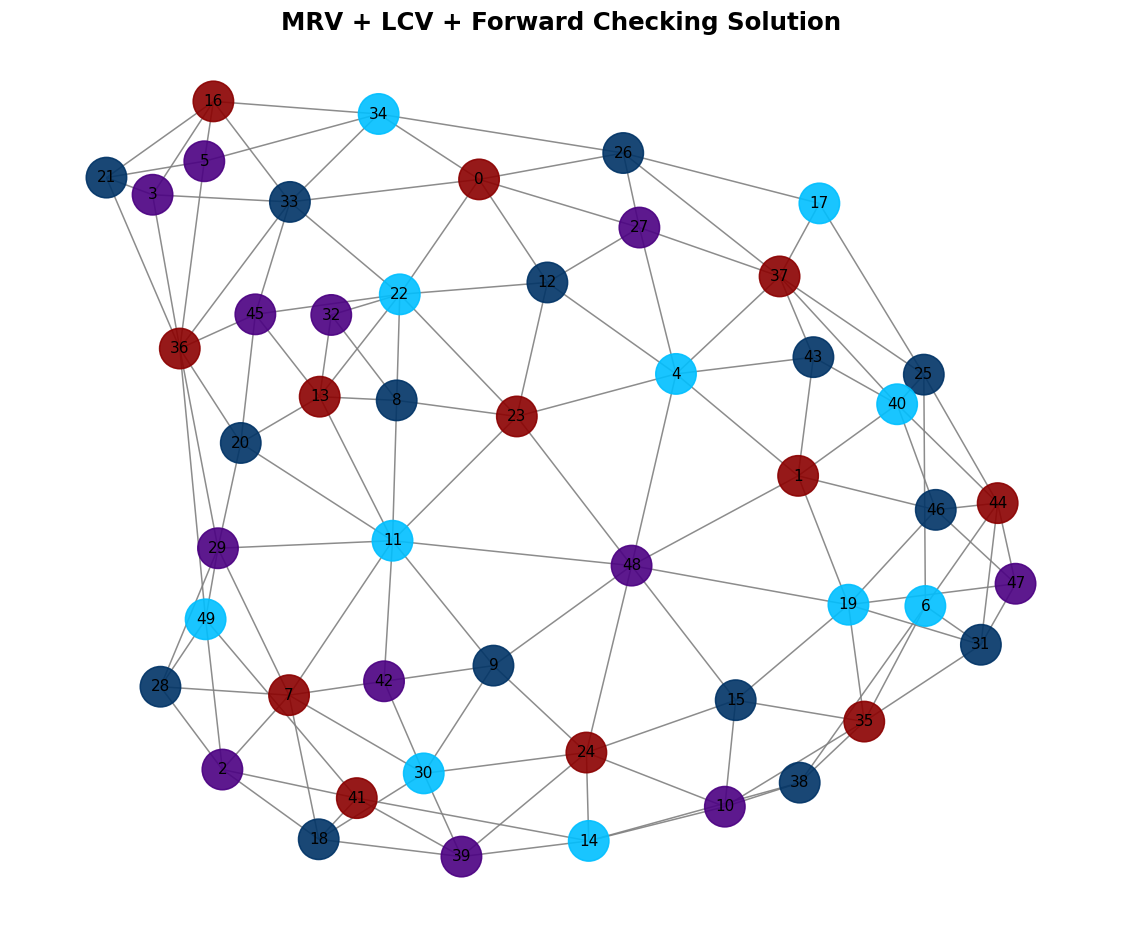

In [9]:
# ============================================================
# 8. MRV + LCV + Forward Checking
# ============================================================

def forward_check(var, value, assignment: dict, domains: dict, neighbors: dict):
	"""
	Forward checking step:
	- Return a new domains dict after assigning (var = value).
	- Remove 'value' from all unassigned neighbors' domains.
	- If any neighbor ends up with an empty domain, return None (failure).
	"""
	domains_copy = copy.deepcopy(domains)
	
	domains_copy[var] = [value]
	
	for neighbor in neighbors.get(var, []):
		if neighbor in assignment:
			continue

		if value in domains_copy.get(neighbor, []):
			domains_copy[neighbor].remove(value)
			if len(domains_copy[neighbor]) == 0:
				return None

	return domains_copy

def backtrack_mrv_lcv_fc(assignment: dict, domains: dict, variables: list, neighbors: dict, stats: dict):
	"""
	Backtracking with:
	- MRV for variable ordering
	- LCV for value ordering
	- Forward Checking as inference
	"""
	stats['calls'] += 1
	
	# All variables assigned?
	if len(assignment) == len(variables):
		return assignment
	
	# MRV variable choice
	var = minimum_remaining_variable(assignment, domains, variables)

	# LCV value ordering
	values = least_constraining_value(var, domains, neighbors)
	for value in values:
		if is_consistent(var, value, assignment, neighbors):
			assignment[var] = value
			new_domains = forward_check(var, value, assignment, domains, neighbors)
			if new_domains is not None:
				result =  backtrack_mrv_lcv_fc(assignment, new_domains, variables, neighbors, stats)
				if result is not None:
					return result

			del assignment[var]

	stats['backtracks'] += 1
	return None

# Run MRV + LCV + Forward Checking
stats_fc = {'calls': 0, 'backtracks': 0}
domains_fc = {var: list(colors) for var in variables}

print("Running MRV + LCV + Forward Checking...")
start = time.time()
solution_fc = backtrack_mrv_lcv_fc({}, domains_fc, variables, neighbors, stats_fc)
time_fc = time.time() - start

print("MRV+LCV+FC solution found?" , solution_fc is not None)
print(f"MRV+LCV+FC: time = {time_fc:.4f}s, calls = {stats_fc['calls']}, backtracks = {stats_fc['backtracks']}")

if solution_fc is not None:
	draw_colored_map(G, solution_fc, title="MRV + LCV + Forward Checking Solution")


## 9. Comparing All Strategies

Let’s gather the metrics for all four solvers:

1. **Naive Backtracking**
2. **MRV + LCV (static domains; “paradox” version)**
3. **MRV + LCV + incremental filtering**
4. **MRV + LCV + Forward Checking**


In [10]:
# ============================================================
# 9. Summary of Results
# ============================================================

print("===== Summary of Results =====")
print(f"Naive:                      time = {time_naive:.4f}s, calls = {stats_naive['calls']}, backtracks = {stats_naive['backtracks']}")
print(f"MRV + LCV (static):         time = {time_mrv_lcv_static:.4f}s, calls = {stats_mrv_lcv_static['calls']}, backtracks = {stats_mrv_lcv_static['backtracks']}")
print(f"MRV + LCV (incremental):    time = {time_mrv_lcv_inc:.4f}s, calls = {stats_mrv_lcv_inc['calls']}, backtracks = {stats_mrv_lcv_inc['backtracks']}")
print(f"MRV + LCV + Forward Check:  time = {time_fc:.4f}s, calls = {stats_fc['calls']}, backtracks = {stats_fc['backtracks']}")


===== Summary of Results =====
Naive:                      time = 18.7504s, calls = 6721394, backtracks = 6721343
MRV + LCV (static):         time = 55.7098s, calls = 6721394, backtracks = 6721343
MRV + LCV (incremental):    time = 0.0049s, calls = 51, backtracks = 0
MRV + LCV + Forward Check:  time = 0.0081s, calls = 51, backtracks = 0


### Concept Check : What Did We Learn?

Reflect on the summary:

1. **Naive vs MRV+LCV (static)**  


2. **Incremental Filtering vs Static**  


3. **Forward Checking**  

### Answer:
Naive backtracking tried over 6.7 million possibilities and took 19 seconds. Adding smarter heuristics (MRV and LCV) but keeping the domains unchanged didn’t reduce the work; the heuristics had no real effect, only added extra computation, so it took even longer (56 seconds). When we made the domains update after each decision (incremental filtering), everything changed: the heuristics could now see which variable was truly most constrained and which color was least disruptive, and dead ends were caught immediately. The search then needed only 51 steps and finished in milliseconds. Forward checking did the same, because for map coloring a single step of looking ahead is enough.


### Why “Incremental” and “Forward Checking” Look Almost Identical Here

You might notice that:

- **MRV + LCV (incremental)** and  
- **MRV + LCV + Forward Checking**

have **exactly the same number of calls and backtracks**, and almost identical runtimes.

This is *not* a mistake. On this particular CSP (map coloring with binary ≠ constraints and uniform initial domains), our “incremental filtering” and “forward checking” are effectively doing the **same operation** at each step:

1. When we assign a variable `X = c`, we:
   - Fix `X`’s domain to `{c}`.
   - Remove color `c` from the domains of all neighbors of `X`.
   - Immediately fail if any neighbor’s domain becomes empty.

2. We do **not** perform any deeper propagation (e.g., we don’t propagate the consequences of reduced neighbor domains further to their neighbors). We only look *one step ahead*.

This “one-step-ahead pruning” is exactly what **standard forward checking** does in a simple binary CSP like this. Our “incremental” variant just uses a slightly different code structure, but in this notebook:

- Both methods maintain **dynamic domains**, and  
- Both prune neighbors’ domains in the **same way** after each assignment.

Therefore, for this problem instance, they explore **the same (very small) search tree**, leading to:

- The same number of recursive calls,
- The same number of backtracks (zero),
- And very similar total runtime (differences are just minor overhead/noise).

In more complex CSPs or with different implementations, you might see clearer performance differences between “lightweight incremental filtering” and “full forward checking,” but here they are essentially equivalent.
